In [12]:
%reload_ext autoreload
%autoreload 2

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss, consistency_loss, reprojection_loss_2d, add_sup_losses, add_con_losses, add_reproj_losses, match_vision_to_target_cylinders

from debugger import bug_check


In [14]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 3070


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=8,
    in_chans=3,
    embed_dim=384,
    depth=6,
    num_heads=6,
    num_bins=128,
    dropout=0.1,
).to(device)


In [16]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debug=False,
    return_two_pairs=True
)

loader = DataLoader(
    dataset,
    batch_size=12,
    shuffle=True,
    num_workers=0,
)

In [ ]:
# bug_check(0)

if True:
    debug_dataset = SceneTwoPairsDataset(
        root_dir="dataset",
        return_two_pairs=False
    )

    debug_loader = DataLoader(
        debug_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
    )


    batch = next(iter(debug_loader))
    img_a, vision_a, img_b, vision_b, pose_ab, target_cylinders = batch

    OCC_THRESH= 0.5

    reproj_forward = reprojection_loss_2d(
        vision_a[:1],
        vision_b[:1],
        pose_ab[:1],
        occ_thresh=OCC_THRESH,
    )

    print("forward", reproj_forward)

    match_a = match_vision_to_target_cylinders(vision_a, target_cylinders)





forward {'total': tensor(1.8945), 'occ': tensor(0.7181), 'radius': tensor(0.4382), 'depth': tensor(0.7382)}
matched_cylinders:  tensor([[ 5.3022, -3.1061,  0.7941, 50.0000],
        [ 9.3764, -7.2125,  0.7802, 50.0000],
        [ 5.3022, -3.1061,  0.7941, 50.0000],
        [ 9.3764, -7.2125,  0.7802, 50.0000]])
matched_distances:  tensor([2.6062, 9.7189, 1.8598, 2.8786])
matched_indices:  tensor([ 0, 10,  0, 10])
vision_a shape: torch.Size([4, 128, 4])
target_cylinders shape: torch.Size([4, 20, 4])
0 bin: 5 occ: 1.0 radius: 0.3191204071044922 depth: 2.7787020206451416 pred xy: [2.7787020206451416, -2.454646110534668] matched gt: [5.302175998687744, -3.1061174869537354, 0.7941184639930725, 50.0] dist: 2.606210947036743
1 bin: 1 occ: 1.0 radius: 0.7758126258850098 depth: 15.295045852661133 pred xy: [15.295045852661133, -14.921297073364258] matched gt: [9.376367568969727, -7.212486743927002, 0.7802409529685974, 50.0] dist: 9.718873977661133
2 bin: 26 occ: 1.0 radius: 0.5993046760559082 de

In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Hyperparameters
LAMBDA_CONS = 1.0
LAMBDA_OCC = 10.0
LAMBDA_RADIUS = 10.0
OCC_THRESH= 0.5

LAMBDA_REPROJ = 10.0

history = {
    "total": [],
    "supervised": [],
    "vision": [],
    "pose": [],
    "consistency": [],
    "cons_occ": [],
    "cons_radius": [],
    "cons_depth": [],
    "reprojection": [],
    "reproj_occ": [],
    "reproj_radius": [],
    "reproj_depth": [],
}

model.train()
for epoch in range(50):
    total = 0.0
    total_vis1 = 0.0
    total_radius1 = 0.0
    total_depth1 = 0.0
    total_pose1 = 0.0
    total_t1 = 0.0
    total_r1 = 0.0

    total_vis2 = 0.0
    total_radius2 = 0.0
    total_depth2 = 0.0
    total_pose2 = 0.0
    total_t2 = 0.0
    total_r2 = 0.0

    total_cons_loss = 0.0
    total_cons_occ = 0.0
    total_cons_rad = 0.0
    total_cons_dep = 0.0

    total_reproj_loss = 0.0
    total_reproj_occ = 0.0
    total_reproj_rad = 0.0
    total_reproj_dep = 0.0


    for batch in loader:
        # img_a1, vision_a1, img_b1, pose_ab1 = batch
        img_a1, vision_a1, img_b1, vision_b1, pose_ab1, target_cylinders1, img_a2, vision_a2, img_b2, vision_b2, pose_ab2, target_cylinders2 = batch

        img_a1 = img_a1.to(device, non_blocking=True)
        img_b1 = img_b1.to(device, non_blocking=True)
        vision_a1 = vision_a1.to(device, non_blocking=True)
        vision_b1 = vision_b1.to(device, non_blocking=True)
        pose_ab1 = pose_ab1.to(device, non_blocking=True)
        img_a2 = img_a2.to(device, non_blocking=True)
        img_b2 = img_b2.to(device, non_blocking=True)
        vision_a2 = vision_a2.to(device, non_blocking=True)
        vision_b2 = vision_b2.to(device, non_blocking=True)
        pose_ab2 = pose_ab2.to(device, non_blocking=True)

        pred_vision_a1, pred_vision_b1, pred_pose1 = model(img_a1, img_b1)
        pred_vision_a2, pred_vision_b2, pred_pose2 = model(img_a2, img_b2)

        loss_out1 = supervised_loss(pred_vision_a1, vision_a1, pred_vision_b1, vision_b1, pred_pose1, pose_ab1,
                                    occ_thresh=OCC_THRESH,
                                    lambda_occ=LAMBDA_OCC,
                                    lambda_radius=LAMBDA_RADIUS,
        )

        loss_out2 = supervised_loss(pred_vision_a2, vision_a2, pred_vision_b2, vision_b2, pred_pose2, pose_ab2,
                                    occ_thresh=OCC_THRESH,
                                    lambda_occ=LAMBDA_OCC,
                                    lambda_radius=LAMBDA_RADIUS,
        )

        cons_loss1 = consistency_loss(
                    pred_vision_a1,
                    pred_vision_a2,
                    occ_thresh=0.3,
                    match_thresh=0.75,
        )

        cons_loss2 = consistency_loss(
                    pred_vision_b1,
                    pred_vision_b2,
                    occ_thresh=0.3,
                    match_thresh=0.75,
        )

        reproj = reprojection_loss_2d(
            pred_vision_a1,
            pred_vision_b1,
            pred_pose1,
            occ_thresh=OCC_THRESH,
        )


        sup_loss = loss_out1["total"] + loss_out2["total"]
        cons_loss = (cons_loss1["total"] + cons_loss2["total"]) / 0.2

        #loss = sup_loss + LAMBDA_CONS * cons_loss + lambda_reproj * reproj["total"]
        loss = sup_loss # + LAMBDA_REPROJ * reproj["total"]

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()

        total_vis1, total_radius1, total_pose1, total_depth1, total_t1, total_r1 = add_sup_losses(
            total_vis1, total_radius1, total_pose1, total_depth1, total_t1, total_r1, loss_out1
        )
        total_vis2, total_radius2, total_pose2, total_depth2, total_t2, total_r2 = add_sup_losses(
            total_vis2, total_radius2, total_pose2, total_depth2, total_t2, total_r2, loss_out2
        )

        total_cons_loss, total_cons_occ, total_cons_rad, total_cons_dep = add_con_losses(
            total_cons_loss, total_cons_occ, total_cons_rad, total_cons_dep, cons_loss1
        )
        
        total_reproj_loss, total_reproj_occ, total_reproj_rad, total_reproj_dep = add_reproj_losses(
            total_reproj_loss, total_reproj_occ, total_reproj_rad, total_reproj_dep, reproj
        )

    n = len(loader)

    epoch_total = total / n
    epoch_vision = (total_vis1 + total_vis2) / (2.0 * n)
    epoch_pose = (total_pose1 + total_pose2) / (2.0 * n)
    epoch_supervised = epoch_vision + epoch_pose
    epoch_consistency = total_cons_loss / n
    epoch_reprojection = total_reproj_loss / n

    history["total"].append(epoch_total)
    history["supervised"].append(epoch_supervised)
    history["vision"].append(epoch_vision)
    history["pose"].append(epoch_pose)
    history["consistency"].append(epoch_consistency)
    history["cons_occ"].append(total_cons_occ / n)
    history["cons_radius"].append(total_cons_rad / n)
    history["cons_depth"].append(total_cons_dep / n)
    history["reprojection"].append(epoch_reprojection)
    history["reproj_occ"].append(total_reproj_occ / n)
    history["reproj_radius"].append(total_reproj_rad / n)
    history["reproj_depth"].append(total_reproj_dep / n)

    print(
        f"Epoch {epoch+1}: "
        f"tot={total/n:.4f} | "
        f"vis={total_vis1/n:.4f} | "
        #f"r={total_radius1/n:.4f} | "
        #f"d={total_depth1/n:.4f} | "
        #f"pose={total_pose1/n:.4f} | "
        #f"t={total_t1/n:.4f} | "
        #f"r={total_r1/n:.4f} | "
        # f"cons={total_cons_loss/n:.4f} | "
        # f"occ={total_cons_occ/n:.4f} | "
        # f"cons_r={total_cons_rad/n:.4f} | "
        # f"cons_d={total_cons_dep/n:.4f}"
        f"reproj={total_reproj_loss/n:.4f} | "
        f"occ={total_reproj_occ/n:.4f} | "
        f"reproj_r={total_reproj_rad/n:.4f} | "
        f"reproj_d={total_reproj_dep/n:.4f}"
    )


Epoch 1: tot=40.5190 | vis=20.0482 | reproj=0.6596 | occ=0.3332 | reproj_r=0.0649 | reproj_d=0.2615
Epoch 2: tot=35.9710 | vis=17.6828 | reproj=0.6201 | occ=0.3967 | reproj_r=0.0346 | reproj_d=0.1888
Epoch 3: tot=32.2893 | vis=15.8799 | reproj=0.0000 | occ=0.0000 | reproj_r=0.0000 | reproj_d=0.0000
Epoch 4: tot=28.3409 | vis=13.7833 | reproj=0.0000 | occ=0.0000 | reproj_r=0.0000 | reproj_d=0.0000
Epoch 5: tot=22.7847 | vis=11.2011 | reproj=0.0000 | occ=0.0000 | reproj_r=0.0000 | reproj_d=0.0000
Epoch 6: tot=19.4140 | vis=9.5603 | reproj=0.0000 | occ=0.0000 | reproj_r=0.0000 | reproj_d=0.0000
Epoch 7: tot=18.9843 | vis=9.2272 | reproj=0.0000 | occ=0.0000 | reproj_r=0.0000 | reproj_d=0.0000
Epoch 8: tot=18.7853 | vis=9.1748 | reproj=0.0000 | occ=0.0000 | reproj_r=0.0000 | reproj_d=0.0000
Epoch 9: tot=18.8824 | vis=9.1694 | reproj=0.0000 | occ=0.0000 | reproj_r=0.0000 | reproj_d=0.0000
Epoch 10: tot=18.8383 | vis=9.1704 | reproj=0.0000 | occ=0.0000 | reproj_r=0.0000 | reproj_d=0.0000
Epoc

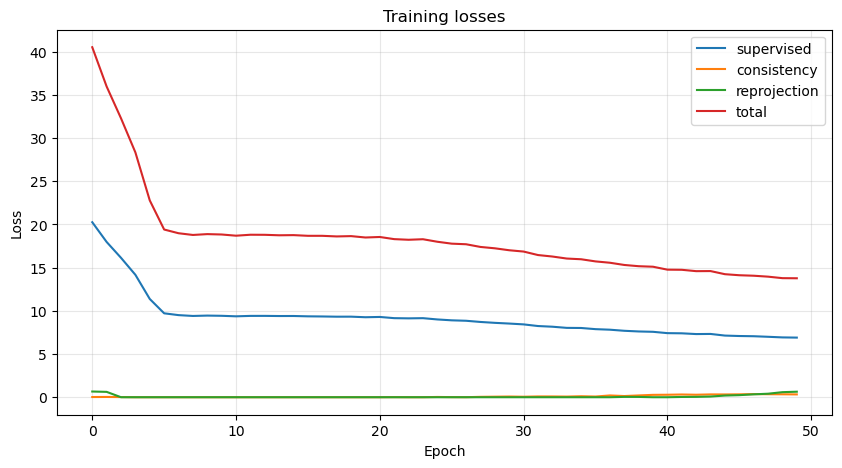

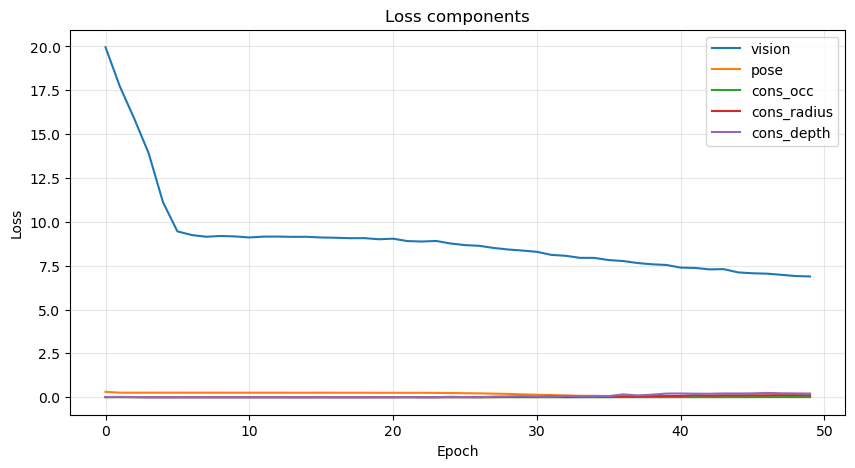

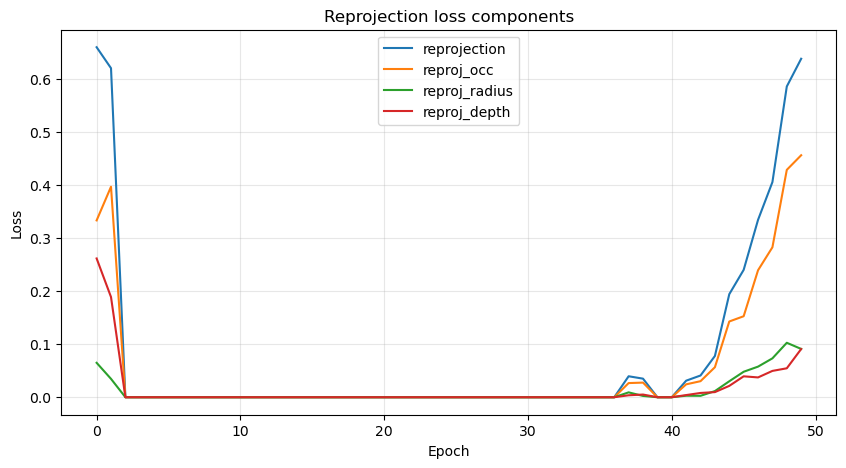

In [19]:
# Plot efter träning
plt.figure(figsize=(10, 5))
plt.plot(history["supervised"], label="supervised")
plt.plot(history["consistency"], label="consistency")
plt.plot(history["reprojection"], label="reprojection")
plt.plot(history["total"], label="total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["vision"], label="vision")
plt.plot(history["pose"], label="pose")
plt.plot(history["cons_occ"], label="cons_occ")
plt.plot(history["cons_radius"], label="cons_radius")
plt.plot(history["cons_depth"], label="cons_depth")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["reprojection"], label="reprojection")
plt.plot(history["reproj_occ"], label="reproj_occ")
plt.plot(history["reproj_radius"], label="reproj_radius")
plt.plot(history["reproj_depth"], label="reproj_depth")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reprojection loss components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Inference + utskrift + plottar på samma dataset som träningen
from utils import pose_to_text, show_image_pair

infer_dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    return_two_pairs=False
)

infer_loader = DataLoader(
    infer_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)
model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab, _ = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
vision_b = vision_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, _, pred_pose = model(img_a, img_b)


# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

Sample 0
  GT   pose: tx=0.245, ty=-0.969, yaw=-3.2°
  Pred pose: tx=0.170, ty=-0.918, yaw=-2.8°
  |err|     : tx=0.075, ty=0.051, sin=0.007, cos=0.000

Sample 1
  GT   pose: tx=-0.180, ty=0.984, yaw=2.2°
  Pred pose: tx=-0.118, ty=1.099, yaw=-0.1°
  |err|     : tx=0.062, ty=0.115, sin=0.040, cos=0.001

Sample 2
  GT   pose: tx=0.234, ty=-0.972, yaw=-5.1°
  Pred pose: tx=0.218, ty=-0.998, yaw=-6.7°
  |err|     : tx=0.015, ty=0.025, sin=0.028, cos=0.003

Sample 3
  GT   pose: tx=-0.460, ty=-0.888, yaw=-1.8°
  Pred pose: tx=-0.416, ty=-0.817, yaw=-2.7°
  |err|     : tx=0.044, ty=0.071, sin=0.016, cos=0.001



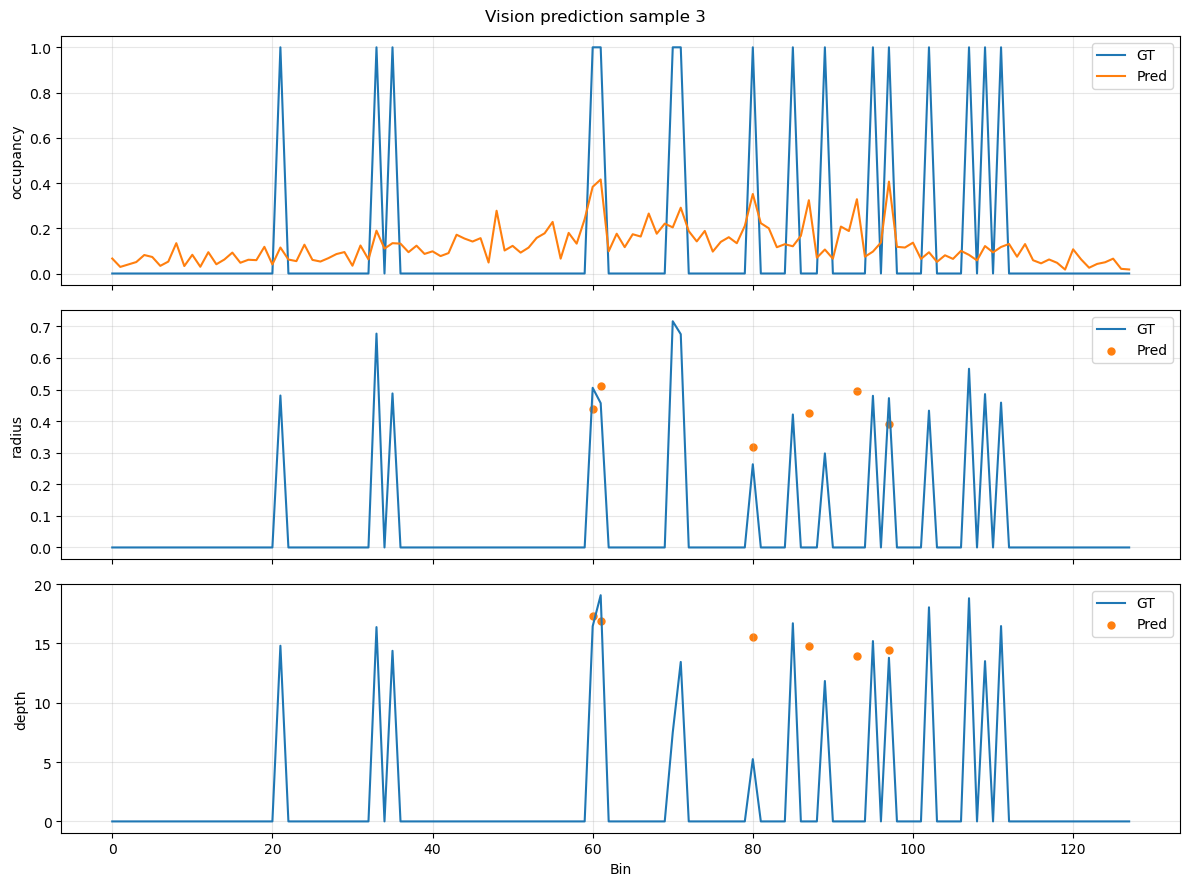

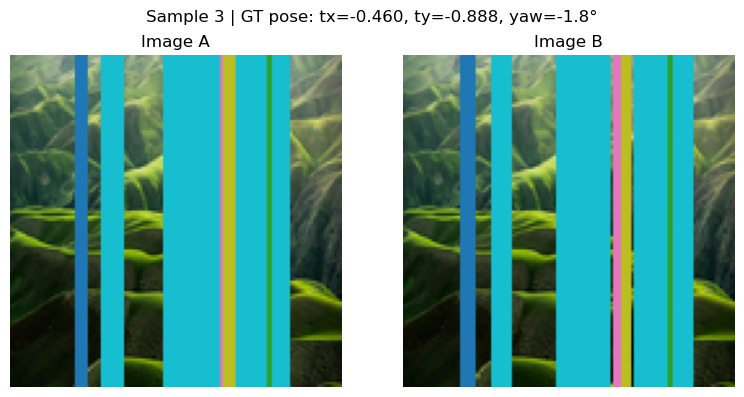

In [21]:
# Plotta vision-output för första samplet
sample_idx = 3
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
occ_threshold = 0.3

gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    # GT alltid blå linje
    ax.plot(bins, gt, label="GT", color="tab:blue")

    if j == 0:
        # occupancy: pred som orange linje
        ax.plot(bins, pr, label="Pred", color="tab:orange")
    else:
        pr_mask = pr_occ > occ_threshold

        # pred som orange punkter
        ax.scatter(
            bins[pr_mask],
            pr[pr_mask],
            label="Pred",
            color="tab:orange",
            s=25
        )

    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()

# Plotta bildpar
show_image_pair(
    img_a[sample_idx].detach().cpu(),
    img_b[sample_idx].detach().cpu(),
    title=f"Sample {sample_idx} | GT pose: {pose_to_text(pose_ab[sample_idx].detach().cpu())}"
)

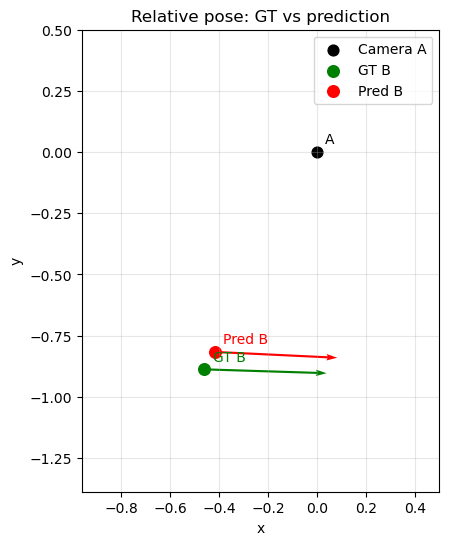

pred_vision shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([-0.4602, -0.8878, -0.0313,  0.9995])
Pred pose: tensor([-0.4161, -0.8167, -0.0475,  0.9989])


In [22]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from utils import plot_relative_pose


# Visa första paret i batchen
if False:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())